# Epileptic Seizure Detection Using Deep Learning
**Dataset:** UCI Epileptic Seizure Recognition  
**Models:** 1D CNN · LSTM · CNN-LSTM Hybrid  
**Task:** Binary Classification — Seizure vs Non-Seizure

## 1. Imports & Configuration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense,
                                      Dropout, Flatten, BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('model', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


In [5]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Data Loading & Exploration

In [6]:
df = pd.read_csv('data/Epileptic Seizure Recognition.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [7]:
print('Dataset Info:')
print(f'  Rows: {df.shape[0]}')
print(f'  Columns: {df.shape[1]}')
print(f'  Missing values: {df.isnull().sum().sum()}')
print()
print('Class Distribution:')
print(df['y'].value_counts().sort_index())
print()
print('Class Meaning:')
print('  1 = Seizure activity (epileptic)')
print('  2 = Tumour area (non-seizure)')
print('  3 = Healthy area (non-seizure)')
print('  4 = Eyes closed (non-seizure)')
print('  5 = Eyes open (non-seizure)')

Dataset Info:
  Rows: 11500
  Columns: 180
  Missing values: 0

Class Distribution:
y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64

Class Meaning:
  1 = Seizure activity (epileptic)
  2 = Tumour area (non-seizure)
  3 = Healthy area (non-seizure)
  4 = Eyes closed (non-seizure)
  5 = Eyes open (non-seizure)


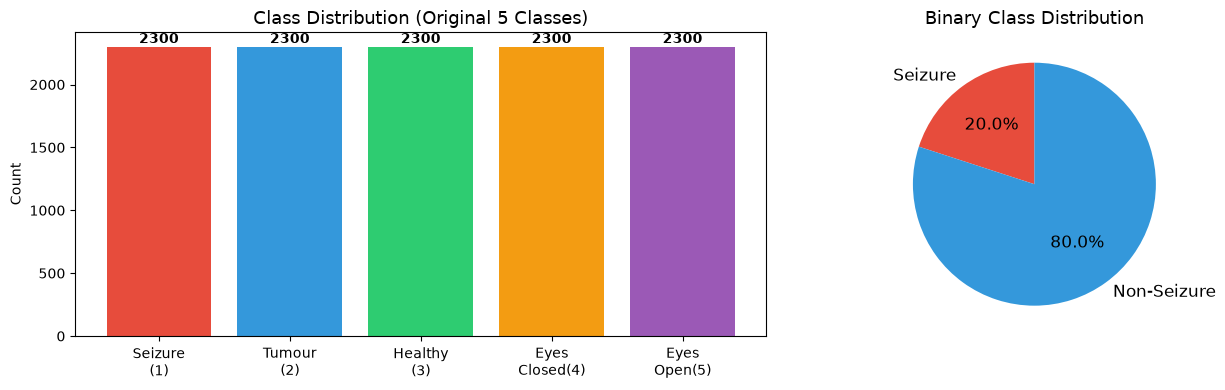

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution bar chart
class_labels = ['Seizure\n(1)', 'Tumour\n(2)', 'Healthy\n(3)', 'Eyes\nClosed(4)', 'Eyes\nOpen(5)']
counts = df['y'].value_counts().sort_index()
axes[0].bar(class_labels, counts.values, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'])
axes[0].set_title('Class Distribution (Original 5 Classes)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Binary class distribution
binary_counts = [(df['y'] == 1).sum(), (df['y'] != 1).sum()]
axes[1].pie(binary_counts, labels=['Seizure', 'Non-Seizure'],
            colors=['#e74c3c', '#3498db'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Binary Class Distribution', fontsize=13)

plt.tight_layout()
plt.savefig('outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

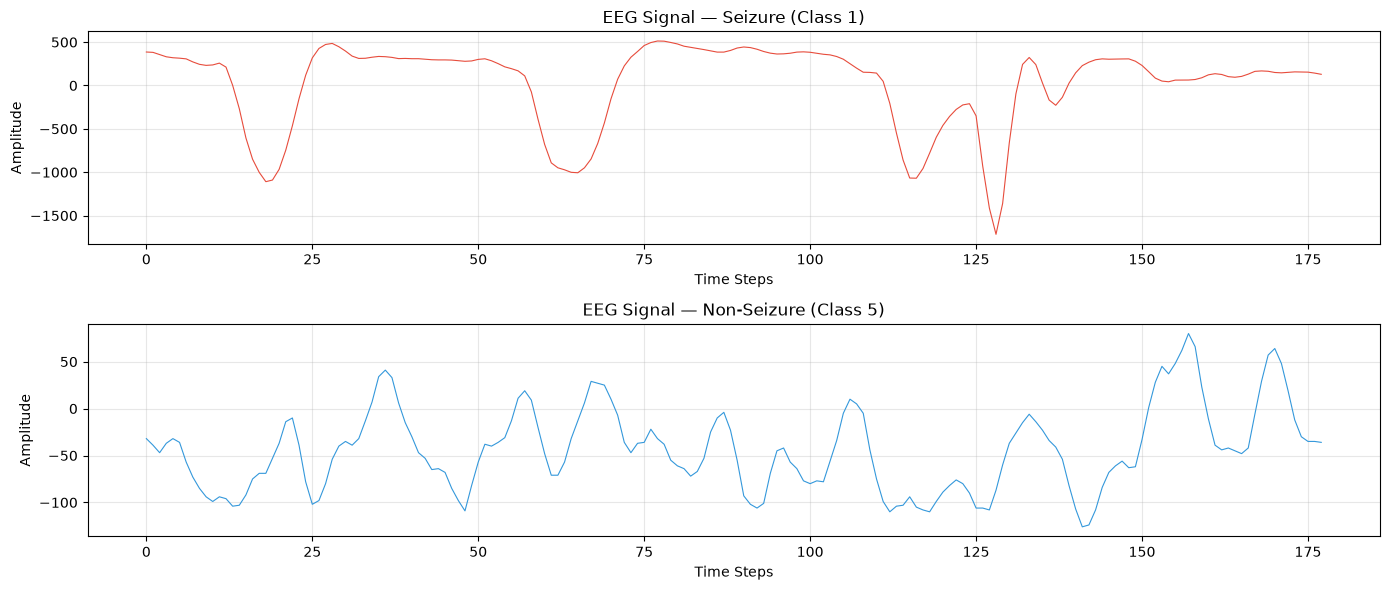

In [9]:
# Visualize sample EEG signals
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

seizure_sample = df[df['y'] == 1].iloc[0, 1:-1].values
non_seizure_sample = df[df['y'] == 5].iloc[0, 1:-1].values

axes[0].plot(seizure_sample, color='#e74c3c', linewidth=0.8)
axes[0].set_title('EEG Signal — Seizure (Class 1)', fontsize=12)
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Amplitude')
axes[0].grid(alpha=0.3)

axes[1].plot(non_seizure_sample, color='#3498db', linewidth=0.8)
axes[1].set_title('EEG Signal — Non-Seizure (Class 5)', fontsize=12)
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Amplitude')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/sample_eeg_signals.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [10]:
# Drop ID column, separate features and labels
df_clean = df.drop(columns=['Unnamed'])
X = df_clean.drop(columns=['y']).values
y = (df_clean['y'] == 1).astype(int).values   # 1 = seizure, 0 = non-seizure

print('Features shape:', X.shape)
print('Labels shape:', y.shape)
print(f'Seizure samples: {y.sum()} ({y.mean()*100:.1f}%)')
print(f'Non-seizure samples: {(1-y).sum()} ({(1-y).mean()*100:.1f}%)')

Features shape: (11500, 178)
Labels shape: (11500,)
Seizure samples: 2300 (20.0%)
Non-seizure samples: 9200 (80.0%)


In [11]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize — fit only on training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape to (samples, timesteps, channels) for CNN/LSTM
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print('Train set:', X_train_3d.shape, '| Labels:', y_train.shape)
print('Test set: ', X_test_3d.shape, '| Labels:', y_test.shape)

Train set: (9200, 178, 1) | Labels: (9200,)
Test set:  (2300, 178, 1) | Labels: (2300,)


## 4. Model Definitions

In [12]:
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=0),
        ModelCheckpoint(f'model/{model_name}.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

### Model 1: 1D CNN

In [13]:
def build_cnn(input_shape=(178, 1)):
    model = Sequential([
        Input(shape=input_shape),

        Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='1D_CNN')

    model.compile(optimizer=Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 178, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 178, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 89, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 89, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 89, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 89, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 44, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 44, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 22, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5632)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       721,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871,169 (3.32 MB)

 Trainable params: 870,273 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [14]:
print('Training 1D CNN...')
cnn_history = cnn_model.fit(
    X_train_3d, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.15,
    callbacks=get_callbacks('cnn_model'),
    verbose=1
)

Training 1D CNN...
Epoch 1/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9238 - loss: 0.2539

62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9444 - loss: 0.1841 - val_accuracy: 0.8623 - val_loss: 0.5818 - learning_rate: 0.0010
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9597 - loss: 0.1152 - val_accuracy: 0.8232 - val_loss: 1.1105 - learning_rate: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9660 - loss: 0.1061 - val_accuracy: 0.8471 - val_loss: 0.9841 - learning_rate: 0.0010
Epoch 4/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9701 - loss: 0.0974

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9714 - loss: 0.0969 - val_accuracy: 0.8775 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 5/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9779 - loss: 0.0668

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9766 - loss: 0.0727 - val_accuracy: 0.8942 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 6/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9801 - loss: 0.0585

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9803 - loss: 0.0602 - val_accuracy: 0.9116 - val_loss: 0.4861 - learning_rate: 5.0000e-04
Epoch 7/30
60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9837 - loss: 0.0504

...

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9928 - loss: 0.0191 - val_accuracy: 0.9638 - val_loss: 0.1118 - learning_rate: 5.0000e-04
Epoch 18/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9923 - loss: 0.0219 - val_accuracy: 0.9587 - val_loss: 0.1242 - learning_rate: 5.0000e-04
Epoch 19/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9935 - loss: 0.0172

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9932 - loss: 0.0193 - val_accuracy: 0.9652 - val_loss: 0.1081 - learning_rate: 5.0000e-04
Epoch 20/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9947 - loss: 0.0159

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9937 - loss: 0.0184 - val_accuracy: 0.9696 - val_loss: 0.0812 - learning_rate: 5.0000e-04
Epoch 21/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9949 - loss: 0.0159

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9936 - loss: 0.0187 - val_accuracy: 0.9703 - val_loss: 0.0837 - learning_rate: 5.0000e-04
Epoch 22/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9923 - loss: 0.0195 - val_accuracy: 0.9674 - val_loss: 0.0806 - learning_rate: 5.0000e-04
Epoch 23/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9939 - loss: 0.0185 - val_accuracy: 0.9696 - val_loss: 0.0867 - learning_rate: 5.0000e-04
Epoch 24/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9939 - loss: 0.0168 - val_accuracy: 0.9681 - val_loss: 0.0956 - learning_rate: 5.0000e-04
Epoch 25/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9959 - loss: 0.0141 - val_accuracy: 0.9703 - val_loss: 0.0897 - learning_rate: 5.0000e-04
Epoch 26/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9920 - loss: 0.0203

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9917 - loss: 0.0207 - val_accuracy: 0.9754 - val_loss: 0.0695 - learning_rate: 5.0000e-04
Epoch 27/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9926 - loss: 0.0182 - val_accuracy: 0.9746 - val_loss: 0.0697 - learning_rate: 5.0000e-04
Epoch 28/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9946 - loss: 0.0171 - val_accuracy: 0.9725 - val_loss: 0.0900 - learning_rate: 5.0000e-04
Epoch 29/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9951 - loss: 0.0119 - val_accuracy: 0.9725 - val_loss: 0.0960 - learning_rate: 5.0000e-04
Epoch 30/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9969 - loss: 0.0099 - val_accuracy: 0.9746 - val_loss: 0.0722 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 26.


### Model 2: LSTM

In [15]:
def build_lstm(input_shape=(178, 1)):
    model = Sequential([
        Input(shape=input_shape),

        LSTM(64, return_sequences=True),
        Dropout(0.3),

        LSTM(32, return_sequences=False),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='LSTM')

    model.compile(optimizer=Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm()
lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 178, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 178, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,489 (123.00 KB)

 Trainable params: 31,489 (123.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
print('Training LSTM...')
lstm_history = lstm_model.fit(
    X_train_3d, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.15,
    callbacks=get_callbacks('lstm_model'),
    verbose=1
)

Training LSTM...
Epoch 1/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8397 - loss: 0.5131

62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.9043 - loss: 0.3419 - val_accuracy: 0.9355 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 2/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9577 - loss: 0.1415

62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.9609 - loss: 0.1320 - val_accuracy: 0.9580 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9685 - loss: 0.1019 - val_accuracy: 0.9362 - val_loss: 0.1897 - learning_rate: 0.0010
Epoch 4/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9700 - loss: 0.0975

62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.9699 - loss: 0.0923 - val_accuracy: 0.9696 - val_loss: 0.0895 - learning_rate: 0.0010
Epoch 5/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9721 - loss: 0.0779

62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9726 - loss: 0.0850 - val_accuracy: 0.9703 - val_loss: 0.0874 - learning_rate: 0.0010
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.9742 - loss: 0.0811 - val_accuracy: 0.9210 - val_loss: 0.2443 - learning_rate: 0.0010
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.9362 - loss: 0.1882 - val_accuracy: 0.9529 - val_loss: 0.1220 - learning_rate: 0.0010
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.9642 - loss: 0.0964 - val_accuracy: 0.9536 - val_loss: 0.1663 - learning_rate: 0.0010
Epoch 9/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9650 - loss: 0.1024 - val_accuracy: 0.9630 - val_loss: 0.0930 - learning_rate: 0.0010
Epoch 10/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9708 - loss: 0.0785 - val_accuracy: 0.9594 - val_loss: 0.0893 - learning_rate: 5.0000e-04
Epoch 11/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9721 - loss: 0.0775 - val_accu

### Model 3: CNN-LSTM Hybrid

In [17]:
def build_cnn_lstm(input_shape=(178, 1)):
    model = Sequential([
        Input(shape=input_shape),

        Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='CNN_LSTM')

    model.compile(optimizer=Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_lstm_model = build_cnn_lstm()
cnn_lstm_model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 178, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 178, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 89, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 89, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 89, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 89, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 44, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,857 (351.00 KB)

 Trainable params: 89,473 (349.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
print('Training CNN-LSTM Hybrid...')
cnn_lstm_history = cnn_lstm_model.fit(
    X_train_3d, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.15,
    callbacks=get_callbacks('cnn_lstm_model'),
    verbose=1
)

Training CNN-LSTM Hybrid...
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9040 - loss: 0.3331

62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9436 - loss: 0.2096 - val_accuracy: 0.9043 - val_loss: 0.2590 - learning_rate: 0.0010
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9719 - loss: 0.0946 - val_accuracy: 0.8870 - val_loss: 0.2989 - learning_rate: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9789 - loss: 0.0654 - val_accuracy: 0.8870 - val_loss: 0.2264 - learning_rate: 0.0010
Epoch 4/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9821 - loss: 0.0527

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9816 - loss: 0.0551 - val_accuracy: 0.9123 - val_loss: 0.1702 - learning_rate: 0.0010
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9851 - loss: 0.0458

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9830 - loss: 0.0509 - val_accuracy: 0.9594 - val_loss: 0.1160 - learning_rate: 0.0010
Epoch 6/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9870 - loss: 0.0414

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9863 - loss: 0.0432 - val_accuracy: 0.9754 - val_loss: 0.0856 - learning_rate: 0.0010
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9868 - loss: 0.0385 - val_accuracy: 0.9746 - val_loss: 0.0967 - learning_rate: 0.0010
Epoch 8/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9900 - loss: 0.0301

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9887 - loss: 0.0338 - val_accuracy: 0.9768 - val_loss: 0.0585 - learning_rate: 0.0010
Epoch 9/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9890 - loss: 0.0345 - val_accuracy: 0.9768 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 10/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9913 - loss: 0.0256

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9907 - loss: 0.0304 - val_accuracy: 0.9848 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 11/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9900 - loss: 0.0272 - val_accuracy: 0.9826 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 12/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9925 - loss: 0.0258 - val_accuracy: 0.9819 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 13/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9918 - loss: 0.0301 - val_accuracy: 0.9841 - val_loss: 0.0505 - learning_rate: 0.0010
Epoch 14/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9905 - loss: 0.0242 - val_accuracy: 0.9841 - val_loss: 0.0467 - learning_rate: 0.0010
Epoch 15/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9937 - loss: 0.0180 - val_accuracy: 0.9841 - val_loss: 0.0478 - learning_rate: 5.0000e-04
Epoch 16/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9952 - loss: 0.0133

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9953 - loss: 0.0137 - val_accuracy: 0.9862 - val_loss: 0.0419 - learning_rate: 5.0000e-04
Epoch 17/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9955 - loss: 0.0128

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9955 - loss: 0.0123 - val_accuracy: 0.9870 - val_loss: 0.0501 - learning_rate: 5.0000e-04
Epoch 18/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9957 - loss: 0.0118 - val_accuracy: 0.9870 - val_loss: 0.0495 - learning_rate: 5.0000e-04
Epoch 19/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9968 - loss: 0.0095 - val_accuracy: 0.9841 - val_loss: 0.0485 - learning_rate: 2.5000e-04
Epoch 20/30
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9969 - loss: 0.0108

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9964 - loss: 0.0114 - val_accuracy: 0.9906 - val_loss: 0.0395 - learning_rate: 2.5000e-04
Epoch 21/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9967 - loss: 0.0090 - val_accuracy: 0.9877 - val_loss: 0.0434 - learning_rate: 2.5000e-04
Epoch 22/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9964 - loss: 0.0072 - val_accuracy: 0.9870 - val_loss: 0.0425 - learning_rate: 2.5000e-04
Epoch 23/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9980 - loss: 0.0066 - val_accuracy: 0.9891 - val_loss: 0.0430 - learning_rate: 2.5000e-04
Epoch 24/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9976 - loss: 0.0074 - val_accuracy: 0.9891 - val_loss: 0.0446 - learning_rate: 2.5000e-04
Epoch 25/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9974 - loss: 0.0071 - val_accuracy: 0.9899 - val_loss: 0.0445 - learning_rate: 1.2500e-04
Epoch 26/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9980 - los

## 5. Training Curves

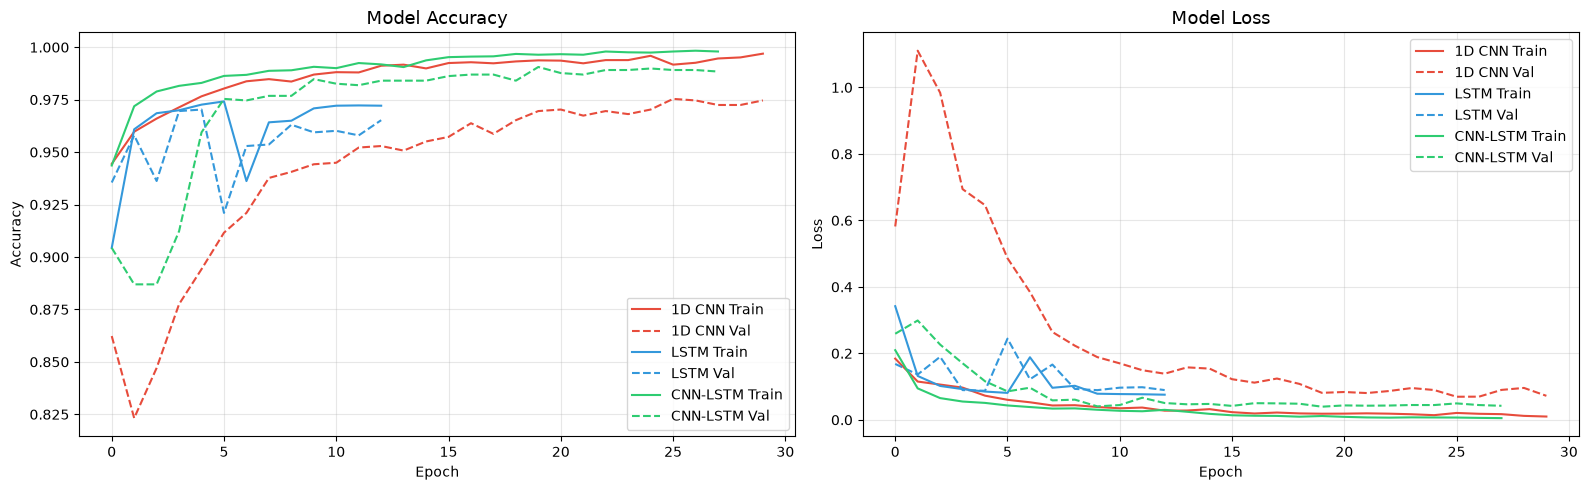

In [19]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = ['#e74c3c', '#3498db', '#2ecc71']

    for hist, name, color in zip(histories, names, colors):
        axes[0].plot(hist.history['accuracy'], label=f'{name} Train', color=color, linewidth=1.5)
        axes[0].plot(hist.history['val_accuracy'], label=f'{name} Val',
                     color=color, linewidth=1.5, linestyle='--')

        axes[1].plot(hist.history['loss'], label=f'{name} Train', color=color, linewidth=1.5)
        axes[1].plot(hist.history['val_loss'], label=f'{name} Val',
                     color=color, linewidth=1.5, linestyle='--')

    axes[0].set_title('Model Accuracy', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Model Loss', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(
    [cnn_history, lstm_history, cnn_lstm_history],
    ['1D CNN', 'LSTM', 'CNN-LSTM']
)

## 6. Model Comparison

In [20]:
models = {
    '1D CNN': cnn_model,
    'LSTM': lstm_model,
    'CNN-LSTM': cnn_lstm_model
}

results = {}
for name, model in models.items():
    loss, acc = model.evaluate(X_test_3d, y_test, verbose=0)
    y_pred_prob = model.predict(X_test_3d, verbose=0).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    results[name] = {
        'accuracy': acc,
        'loss': loss,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'fpr': fpr,
        'tpr': tpr
    }
    print(f'{name:12s} → Accuracy: {acc*100:.2f}%  |  AUC: {roc_auc:.4f}  |  Loss: {loss:.4f}')

best_model_name = max(results, key=lambda k: results[k]['accuracy'])
print(f'\nBest Model: {best_model_name} ({results[best_model_name]["accuracy"]*100:.2f}%)')

1D CNN       → Accuracy: 98.09%  |  AUC: 0.9991  |  Loss: 0.0534
LSTM         → Accuracy: 97.04%  |  AUC: 0.9945  |  Loss: 0.0788
CNN-LSTM     → Accuracy: 99.26%  |  AUC: 0.9993  |  Loss: 0.0258

Best Model: CNN-LSTM (99.26%)


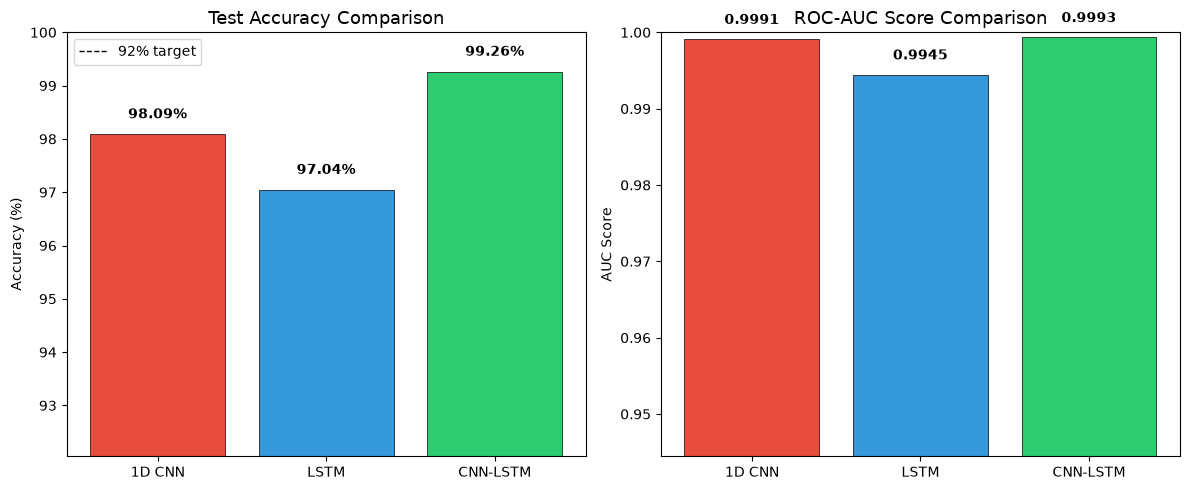

In [21]:
# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in model_names]
aucs = [results[m]['auc'] for m in model_names]
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Test Accuracy Comparison', fontsize=13)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([min(accuracies) - 5, 100])
axes[0].axhline(y=92, color='black', linestyle='--', linewidth=1, label='92% target')
axes[0].legend()
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.2f}%', ha='center', fontweight='bold')

bars2 = axes[1].bar(model_names, aucs, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('ROC-AUC Score Comparison', fontsize=13)
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim([min(aucs) - 0.05, 1.0])
for bar, a in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{a:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Best Model — Detailed Evaluation

In [22]:
best = results[best_model_name]
y_pred_best = best['y_pred']
y_prob_best = best['y_pred_prob']

print(f'Best Model: {best_model_name}')
print('=' * 50)
print(classification_report(y_test, y_pred_best,
                             target_names=['Non-Seizure', 'Seizure']))

Best Model: CNN-LSTM
              precision    recall  f1-score   support

 Non-Seizure       1.00      0.99      1.00      1840
     Seizure       0.97      0.99      0.98       460

    accuracy                           0.99      2300
   macro avg       0.99      0.99      0.99      2300
weighted avg       0.99      0.99      0.99      2300



True Positives  (seizure correctly detected):    456
True Negatives  (non-seizure correctly rejected): 1827
False Positives (false alarms):                  13
False Negatives (missed seizures):               4


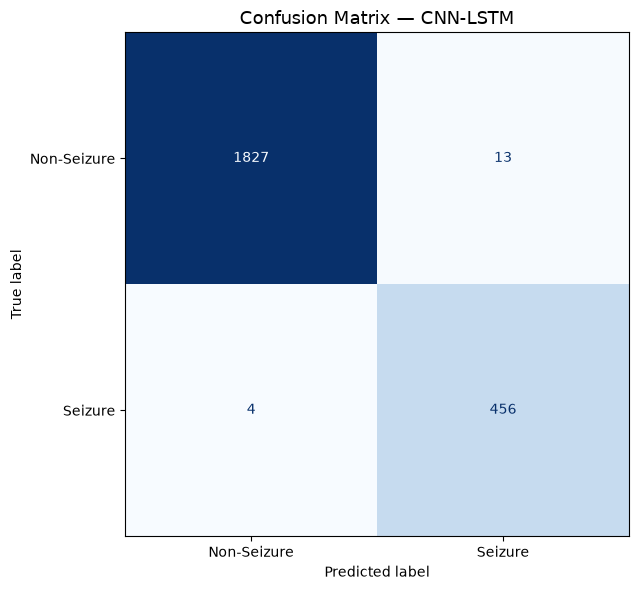

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Seizure', 'Seizure'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13)

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (seizure correctly detected):    {tp}')
print(f'True Negatives  (non-seizure correctly rejected): {tn}')
print(f'False Positives (false alarms):                  {fp}')
print(f'False Negatives (missed seizures):               {fn}')

plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

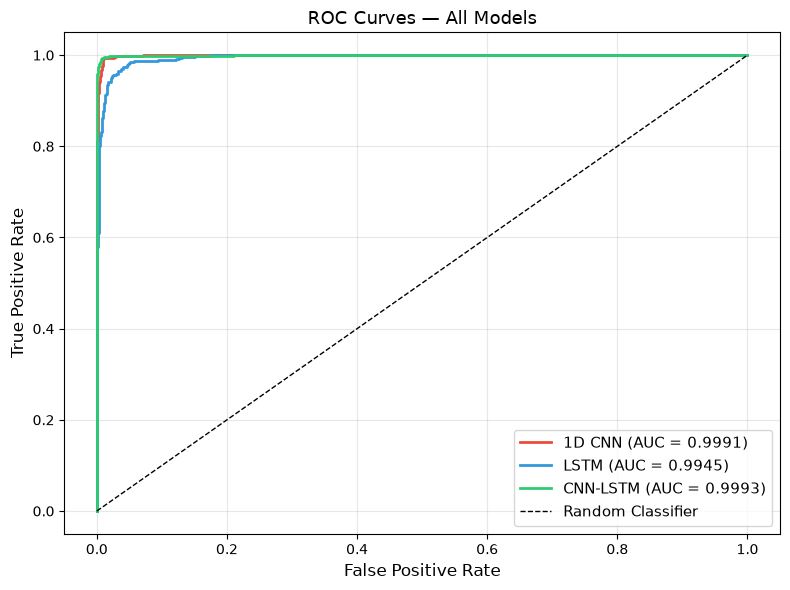

In [24]:
# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71']

for (name, res), color in zip(results.items(), colors_roc):
    ax.plot(res['fpr'], res['tpr'], color=color, linewidth=2,
            label=f"{name} (AUC = {res['auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Best Model

In [25]:
best_model_obj = models[best_model_name]
best_model_obj.save('model/seizure_model.h5')
print(f'Best model ({best_model_name}) saved to model/seizure_model.h5')

print('\nOutputs saved:')
for f in os.listdir('outputs'):
    print(f'  outputs/{f}')

Best model (CNN-LSTM) saved to model/seizure_model.h5

Outputs saved:
  outputs/.gitkeep
  outputs/class_distribution.png
  outputs/confusion_matrix.png
  outputs/eda_amplitude_distribution.png
  outputs/eda_avg_signal_per_class.png
  outputs/eda_class_distribution.png
  outputs/eda_correlation_heatmap.png
  outputs/eda_eeg_signals.png
  outputs/eda_feature_variance.png
  outputs/eda_pca.png
  outputs/eda_signal_stats.png
  outputs/model_comparison.png
  outputs/roc_curve.png
  outputs/sample_eeg_signals.png
  outputs/training_curves.png


## 9. Summary

In [26]:
print('=' * 55)
print('        EPILEPTIC SEIZURE DETECTION — RESULTS')
print('=' * 55)
for name, res in results.items():
    marker = ' <<< BEST' if name == best_model_name else ''
    print(f'  {name:12s}  Accuracy: {res["accuracy"]*100:.2f}%   AUC: {res["auc"]:.4f}{marker}')
print('=' * 55)
print(f'  False Alarms (FP): {fp}')
print(f'  Missed Seizures (FN): {fn}')
print('=' * 55)

        EPILEPTIC SEIZURE DETECTION — RESULTS
  1D CNN        Accuracy: 98.09%   AUC: 0.9991
  LSTM          Accuracy: 97.04%   AUC: 0.9945
  CNN-LSTM      Accuracy: 99.26%   AUC: 0.9993 <<< BEST
  False Alarms (FP): 13
  Missed Seizures (FN): 4
